# Trabajo 1: Análisis geodemográfico del Gran Santiago

**Alumna:** María Núñez  
**Docente:** Matías Escudero  
**Asignatura:** Laboratorio MDG  

## 1. Introducción

El análisis geodemográfico permite estudiar cómo se distribuyen las características de la población dentro de un territorio. En este trabajo se utiliza información del Censo 2017 para analizar dos indicadores demográficos en las comunas del Gran Santiago: el porcentaje de mujeres y el porcentaje de adultos mayores de 65 años o más. Los resultados se representan mediante gráficos de barras y mapas coropléticos, lo que permite comparar las comunas e identificar diferencias espaciales entre ellas.

## 2. Objetivos

### Objetivo general

Analizar la distribución territorial de la población femenina y adulta mayor en las comunas del Gran Santiago a partir de los datos del Censo 2017.

### Objetivos específicos

- Calcular el porcentaje de mujeres por comuna.
- Calcular el porcentaje de personas de 65 años o más por comuna.
- Representar ambos indicadores mediante gráficos de barras y mapas coropléticos.
- Comparar los resultados e identificar diferencias entre las comunas analizadas.

## 3. Metodología

Para desarrollar el análisis se utilizó Python mediante Jupyter Notebook y una base de datos PostgreSQL con información del Censo 2017. Los datos de personas, hogares, viviendas, zonas, comunas y provincias fueron relacionados mediante una consulta SQL. Posteriormente, los resultados se procesaron con las librerías Pandas y GeoPandas, mientras que Matplotlib se utilizó para elaborar los gráficos y mapas.


### 3.1 Librerías utilizadas

Se importaron las librerías necesarias para el manejo de datos, la conexión con PostgreSQL y la elaboración de gráficos y mapas.

In [1]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from adjustText import adjust_text
from sqlalchemy import create_engine

### 3.2 Conexión a la base de datos

Se estableció una conexión con la base de datos PostgreSQL que contiene la información del Censo 2017 de la Región Metropolitana.

In [2]:
from sqlalchemy import create_engine

DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'censo_rm_2017'
DB_USER = 'postgres'
DB_PASSWORD = 'postgres'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print('Conexión exitosa al servidor PostgreSQL')

Conexión exitosa al servidor PostgreSQL


## 4. Resultados

### 4.1 Cálculo de los indicadores

Se seleccionaron dos indicadores demográficos: el porcentaje de mujeres y el porcentaje de adultos mayores. Para identificar a la población femenina se utilizó la variable `p08`, considerando el código 2 correspondiente a mujeres. Para identificar a los adultos mayores se utilizó la variable `p09`, considerando a las personas de 65 años o más.

Mediante una consulta SQL se calcularon ambos porcentajes para cada comuna del Gran Santiago. Posteriormente, los resultados se asociaron con la geometría comunal para permitir su representación en tablas, gráficos y mapas.

In [3]:
sql_nuevos_indicadores = """
WITH agg AS (
    SELECT
        c.nom_comuna,
        ROUND(
            COUNT(*) FILTER (WHERE p.p08 = 2) * 100.0 / COUNT(*), 2
        ) AS ptje_mujeres,
        ROUND(
            COUNT(*) FILTER (WHERE p.p09 >= 65) * 100.0 / COUNT(*), 2
        ) AS ptje_adultos_mayores
    FROM public.personas AS p
    JOIN public.hogares AS h
        ON p.hogar_ref_id = h.hogar_ref_id
    JOIN public.viviendas AS v
        ON h.vivienda_ref_id = v.vivienda_ref_id
    JOIN public.zonas AS z
        ON v.zonaloc_ref_id = z.zonaloc_ref_id
    JOIN public.comunas AS c
        ON z.codigo_comuna = c.codigo_comuna
    JOIN public.provincias AS pr
        ON pr.provincia_ref_id = c.provincia_ref_id
    WHERE pr.nom_provincia = 'SANTIAGO'
       OR c.nom_comuna IN ('PUENTE ALTO', 'SAN BERNARDO')
    GROUP BY c.nom_comuna
)
SELECT
    a.nom_comuna,
    shp.geom,
    a.ptje_mujeres,
    a.ptje_adultos_mayores
FROM agg AS a
JOIN dpa.comunas_rm_shp AS shp
    ON UPPER(shp.nom_comuna) = a.nom_comuna;
"""

### 4.2 Tabla de resultados

La siguiente tabla presenta el porcentaje de mujeres y el porcentaje de adultos mayores calculado para cada una de las comunas analizadas.

In [4]:
import geopandas as gpd

gdf_nuevos = gpd.read_postgis(
    sql_nuevos_indicadores,
    engine,
    geom_col='geom'
)

gdf_nuevos[['nom_comuna', 'ptje_mujeres', 'ptje_adultos_mayores']]

,nom_comuna,ptje_mujeres,ptje_adultos_mayores
0,LO PRADO,51.38,14.55
1,INDEPENDENCIA,50.95,10.97
2,LO ESPEJO,50.26,11.71
3,SAN RAMÓN,50.70,14.61
4,LA CISTERNA,52.12,14.36
5,PEDRO AGUIRRE CERDA,51.06,14.21
6,SAN MIGUEL,53.00,12.77
7,CONCHALÍ,51.26,13.75
8,SAN JOAQUÍN,51.50,14.80
9,LA GRANJA,51.08,11.93


Al comparar los resultados se observa que el porcentaje de mujeres supera el 50 % en casi todas las comunas. Los valores más altos se registran en Vitacura (55,02 %), Ñuñoa (54,18 %), Las Condes (53,90 %) y Providencia (53,75 %). En cambio, Santiago presenta el valor más bajo, con un 48,90 %.

El porcentaje de adultos mayores presenta diferencias más marcadas entre las comunas. Vitacura registra el valor más alto, con un 17,61 %, seguida por Providencia (15,67 %) y Las Condes (15,61 %). Por otra parte, los porcentajes más bajos se encuentran en Quilicura (5,44 %), Santiago (7,42 %), Lo Barnechea (7,58 %) y Puente Alto (7,65 %).

### 4.3 Gráficos de barras

Los siguientes gráficos ordenan las comunas según el valor de cada indicador y permiten comparar con mayor claridad las diferencias existentes.

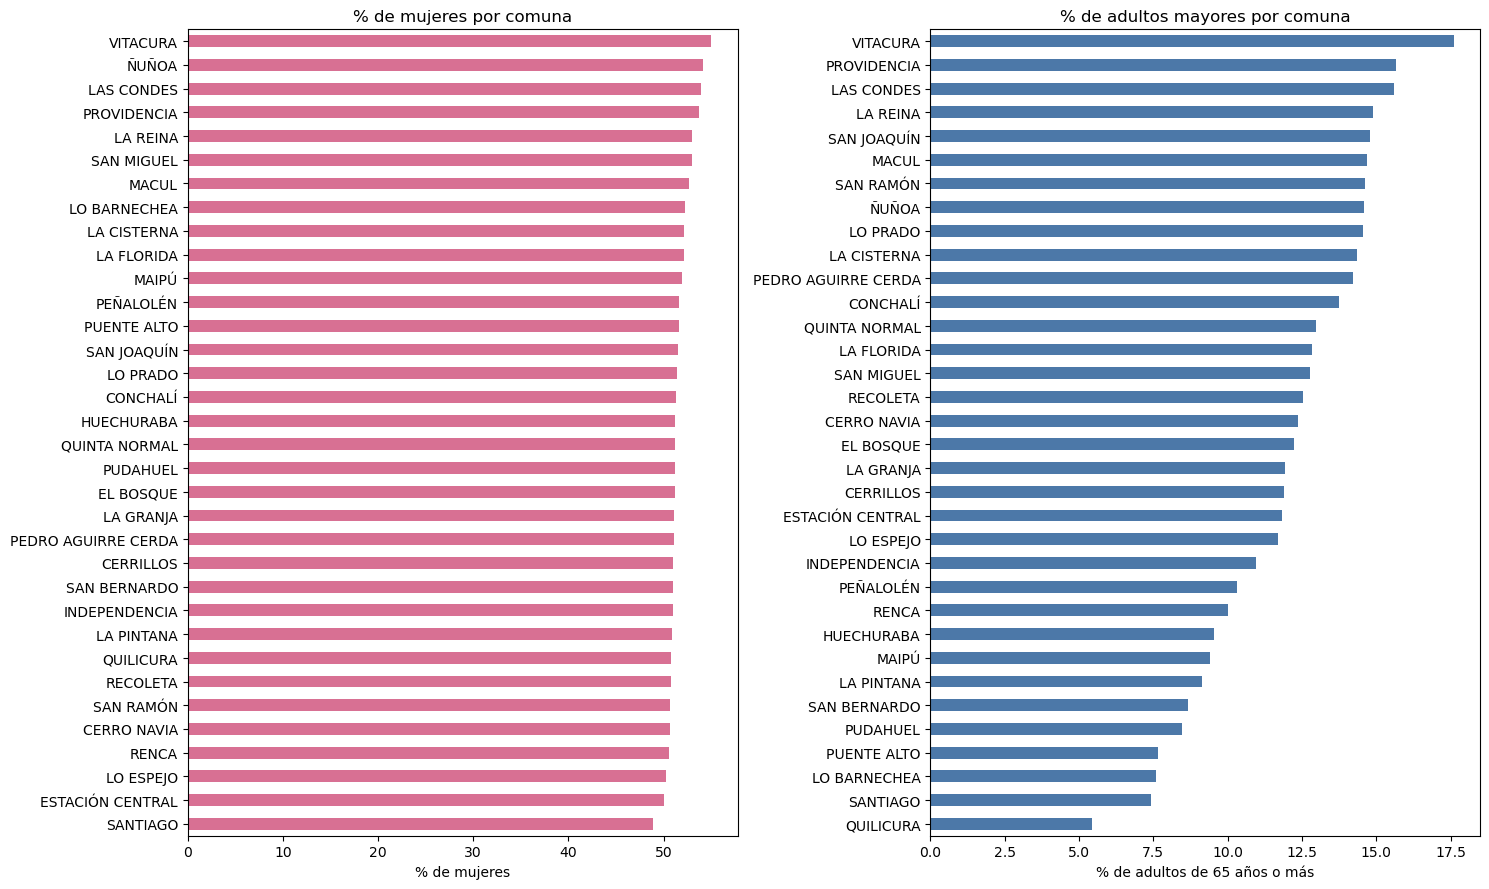

In [5]:
import matplotlib.pyplot as plt

datos = gdf_nuevos.set_index('nom_comuna')

fig, axes = plt.subplots(1, 2, figsize=(15, 9))

datos['ptje_mujeres'].sort_values().plot.barh(
    ax=axes[0],
    color='#d87093'
)
axes[0].set_title('% de mujeres por comuna')
axes[0].set_xlabel('% de mujeres')
axes[0].set_ylabel('')

datos['ptje_adultos_mayores'].sort_values().plot.barh(
    ax=axes[1],
    color='#4c78a8'
)
axes[1].set_title('% de adultos mayores por comuna')
axes[1].set_xlabel('% de adultos de 65 años o más')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

En el gráfico de mujeres se observa que las diferencias entre comunas son relativamente pequeñas, ya que los porcentajes se concentran aproximadamente entre el 49 % y el 55 %. En cambio, el indicador de adultos mayores presenta una variación más amplia, desde un 5,44 % hasta un 17,61 %, lo que evidencia mayores diferencias territoriales en la estructura etaria de la población.

## 5. Representación cartográfica

Los indicadores se representaron mediante mapas coropléticos clasificados en cinco cuantiles. Los tonos más claros corresponden a los porcentajes más bajos, mientras que los tonos más oscuros representan los valores más altos.
### 5.1 Mapa del porcentaje de mujeres

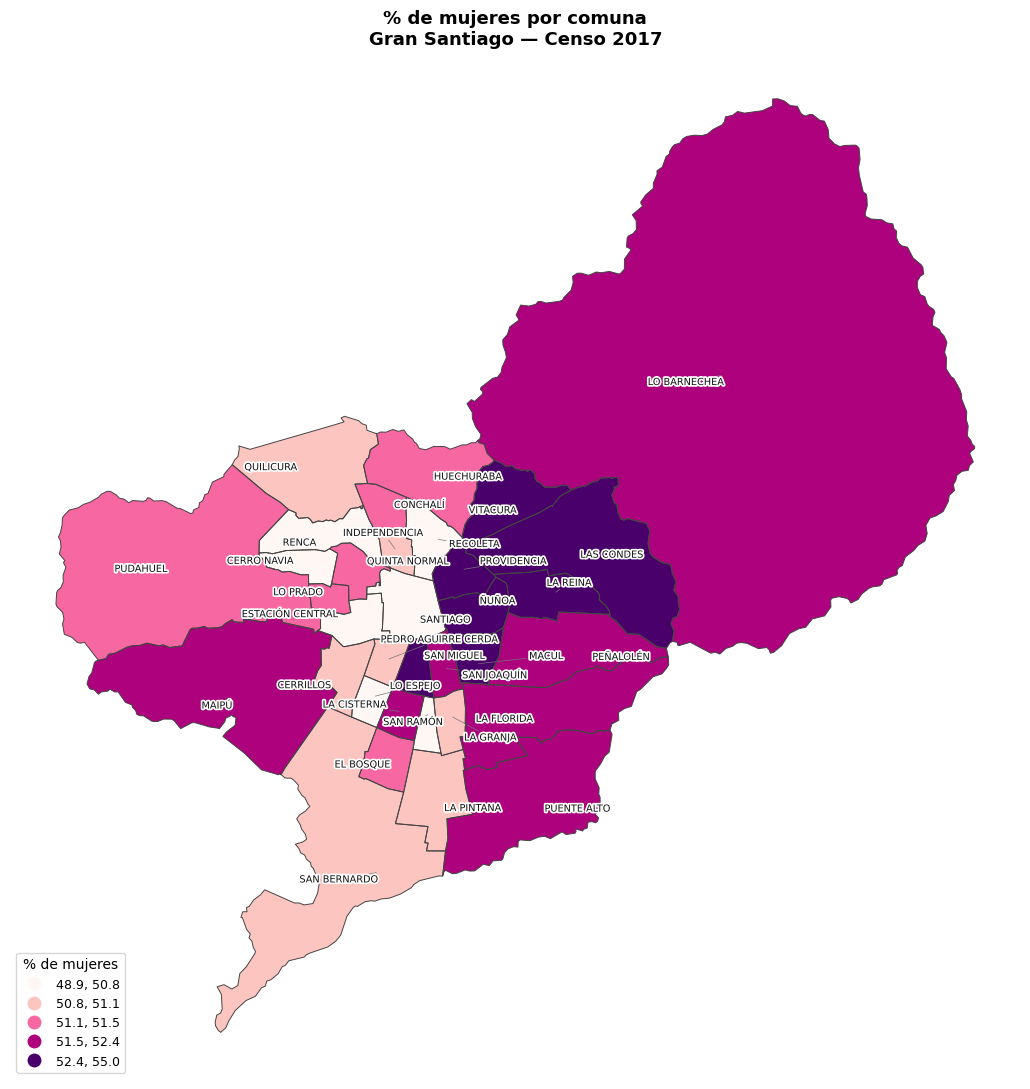

In [6]:
import matplotlib.patheffects as pe
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(11, 11))

gdf_nuevos.plot(
    column='ptje_mujeres',
    cmap='RdPu',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={
        'title': '% de mujeres',
        'loc': 'lower left',
        'fontsize': 9,
        'title_fontsize': 10,
        'fmt': '{:.1f}'
    },
    ax=ax
)

gdf_nuevos.boundary.plot(
    ax=ax,
    color='#444444',
    linewidth=0.7
)

puntos = gdf_nuevos.geometry.representative_point()

textos = [
    ax.text(
        punto.x,
        punto.y,
        nombre,
        ha='center',
        va='center',
        fontsize=7,
        color='#111111',
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground='white')
        ]
    )
    for punto, nombre in zip(
        puntos,
        gdf_nuevos['nom_comuna']
    )
]

adjust_text(
    textos,
    ax=ax,
    arrowprops=dict(
        arrowstyle='-',
        color='#777777',
        lw=0.5
    )
)

ax.set_title(
    '% de mujeres por comuna\nGran Santiago — Censo 2017',
    fontsize=13,
    fontweight='bold'
)

ax.axis('off')
plt.tight_layout()
plt.show()

El mapa muestra que los porcentajes más altos de mujeres se concentran principalmente en comunas del sector oriente y centro-oriente, como Vitacura, Ñuñoa, Las Condes, Providencia y La Reina. En contraste, Santiago, Estación Central, Lo Espejo y Renca se encuentran entre las comunas con menores porcentajes. Sin embargo, las diferencias entre los rangos son reducidas, debido a que la proporción de mujeres es cercana al 50 % en gran parte del territorio analizado.

### 5.2 Mapa del porcentaje de adultos mayores

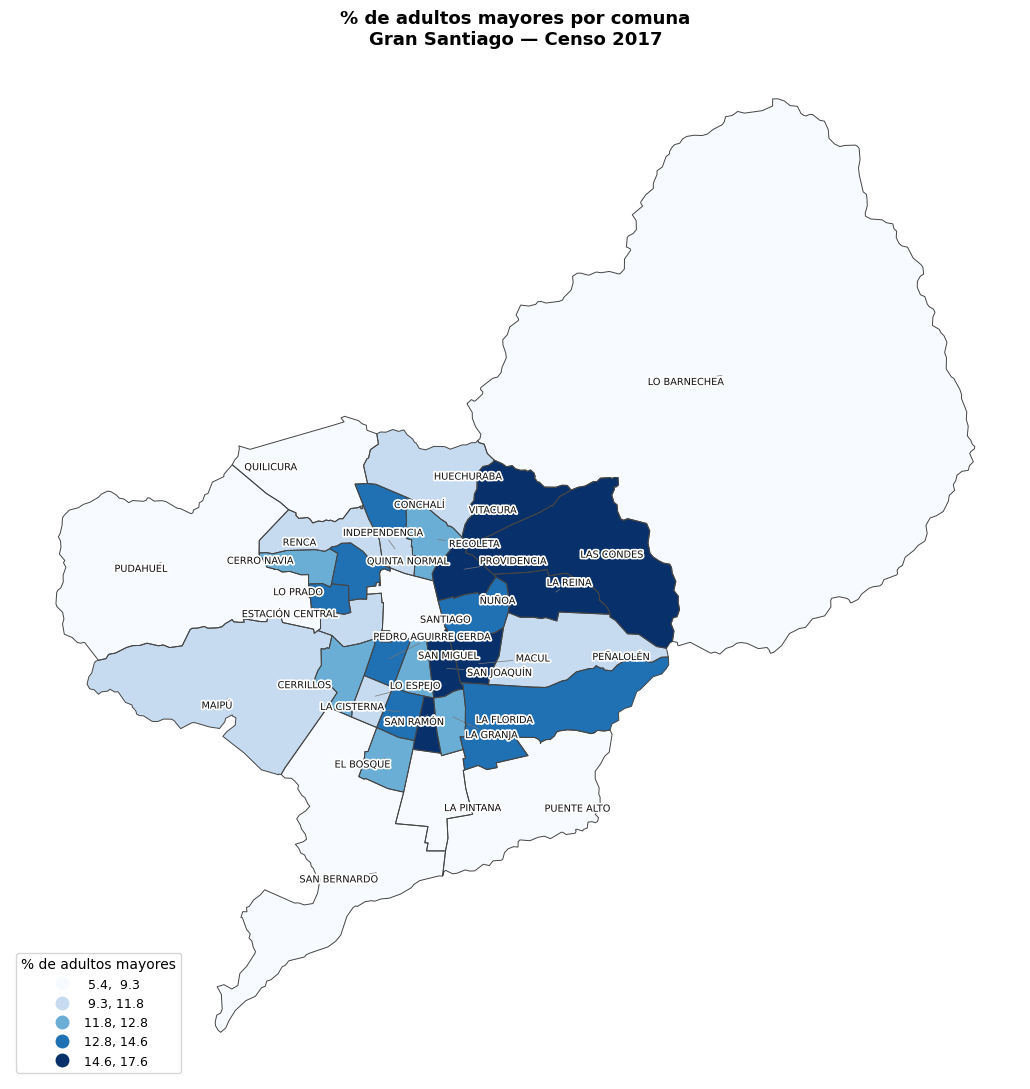

In [7]:
fig, ax = plt.subplots(figsize=(11, 11))

gdf_nuevos.plot(
    column='ptje_adultos_mayores',
    cmap='Blues',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={
        'title': '% de adultos mayores',
        'loc': 'lower left',
        'fontsize': 9,
        'title_fontsize': 10,
        'fmt': '{:.1f}'
    },
    ax=ax
)

gdf_nuevos.boundary.plot(
    ax=ax,
    color='#444444',
    linewidth=0.7
)

puntos = gdf_nuevos.geometry.representative_point()

textos = [
    ax.text(
        punto.x,
        punto.y,
        nombre,
        ha='center',
        va='center',
        fontsize=7,
        color='#111111',
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground='white')
        ]
    )
    for punto, nombre in zip(
        puntos,
        gdf_nuevos['nom_comuna']
    )
]

adjust_text(
    textos,
    ax=ax,
    arrowprops=dict(
        arrowstyle='-',
        color='#777777',
        lw=0.5
    )
)

ax.set_title(
    '% de adultos mayores por comuna\nGran Santiago — Censo 2017',
    fontsize=13,
    fontweight='bold'
)

ax.axis('off')
plt.tight_layout()
plt.show()

El mapa de adultos mayores evidencia diferencias territoriales más notorias. Los porcentajes más altos se observan principalmente en Vitacura, Providencia, Las Condes, La Reina, San Joaquín, Macul y San Ramón. En cambio, comunas como Quilicura, Santiago, Lo Barnechea, Puente Alto, Pudahuel y San Bernardo presentan porcentajes comparativamente menores. La distribución espacial demuestra que la presencia de población adulta mayor no es homogénea entre las comunas del Gran Santiago.

## 6. Conclusiones

El análisis permitió identificar diferencias en la distribución de la población femenina y adulta mayor en las comunas del Gran Santiago. El porcentaje de mujeres se mantiene relativamente cercano al 50 % en la mayoría de las comunas, por lo que sus variaciones territoriales son reducidas. En contraste, el porcentaje de adultos mayores presenta diferencias más amplias entre los territorios analizados.

Los gráficos facilitaron la comparación de los valores comunales, mientras que los mapas permitieron reconocer su distribución espacial. En conjunto, los resultados muestran la utilidad de combinar información censal, consultas SQL y herramientas de representación geográfica para desarrollar análisis geodemográficos a escala comunal.